# Notebook 10 — Theoretical Consistency: State 2-Design & Frame Potential Analysis

**Core Scientific Question:**  
*Does the finite-depth barren plateau onset $\tau_{BP}$ occur because the output state ensemble has converged to a Haar-random state 2-design, or does $\tau_{BP}$ set in well before global state-space scrambling?*

### Key Mathematical & Methodological Corrections:
1. **Unbiased Off-Diagonal U-Statistic Estimator:**  
   For an ensemble of $M$ statevectors $\{|\psi_i\rangle\}_{i=1}^M$ generated from $|0\rangle^{\otimes n}$, the state frame potential is estimated excluding the trivial $i = j$ diagonal self-overlaps ($|\langle\psi_i|\psi_i\rangle|^4 = 1$):
   $$\hat{\mathcal{F}}_2(L) = \frac{1}{M(M-1)} \sum_{i \ne j} |\langle \psi_i(\theta) | \psi_j(\phi) \rangle|^4$$
   Excluding the diagonal terms eliminates the guaranteed $1/M$ floor that would otherwise swamp the theoretical Haar target $\mathcal{F}_2^{\text{Haar}} = \frac{2}{d(d+1)}$ for $n \ge 10$.
2. **State 2-Design vs. Unitary 2-Design:**  
   This calculation measures state-space convergence (projective 2-design) from the initial reference state $|0\rangle^{\otimes n}$. It serves as a diagnostic of state scrambling, which is directly relevant to variational optimization from $|0\rangle^{\otimes n}$.
3. **Physical Parallel Schedules (100% Notebook 7 Alignment):**  
   The 2D Grid uses the exact deterministic greedy edge matchings from Notebook 7. All-to-All uses the circle-method tournament schedule. Each nominal circuit layer represents a single parallel entangling time slice without overlapping CNOT gates.
4. **Full Primary Range:**  
   Includes $n \in \{8, 10, 12, 14, 16\}$.


### Cell 1 — Setup & Configuration


In [1]:
# ============================================================
# CELL 1 — SETUP & CONFIGURATION
# ============================================================

%pip install -q pennylane "numpy<2"

import os
import time
import json
import pickle
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# Full primary range
SYSTEM_SIZES = [8, 10, 12, 14, 16]
MAX_DEPTH = 30
DEPTHS = list(range(1, MAX_DEPTH + 1))
N_ENSEMBLE = 40  # Independent circuit initializations per depth
MASTER_SEED = 20260904

ARCHITECTURES = [
    "brickwall_1d",
    "grid_2d",
    "all_to_all",
]

GRID_SHAPES = {
    8:  (2, 4),
    10: (2, 5),
    12: (3, 4),
    14: (2, 7),
    16: (4, 4),
}

# Empirical tau results from Checkpoint 7
TAU_FILE = "architecture_tau.csv"
if not os.path.exists(TAU_FILE):
    alt_path = os.path.join("notebook7_architecture_generalization", "architecture_tau.csv")
    if os.path.exists(alt_path):
        TAU_FILE = alt_path

OUTPUT_DIR = "notebook10_theory_2design"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "state_frame_potential_checkpoint.pkl")
RAW_OUTPUT = os.path.join(OUTPUT_DIR, "state_frame_potential_curves.csv")
SUMMARY_OUTPUT = os.path.join(OUTPUT_DIR, "state_2design_summary.csv")

print("=" * 80)
print("NOTEBOOK 10 — STATE 2-DESIGN & FRAME POTENTIAL CONSISTENCY")
print("=" * 80)
print(f"System sizes: {SYSTEM_SIZES}")
print(f"Max depth: {MAX_DEPTH}")
print(f"Ensemble size per point: {N_ENSEMBLE}")
print(f"Architectures: {ARCHITECTURES}")
print(f"Input tau dataset: {TAU_FILE}")
print("=" * 80)

Note: you may need to restart the kernel to use updated packages.
NOTEBOOK 10 — STATE 2-DESIGN & FRAME POTENTIAL CONSISTENCY
System sizes: [8, 10, 12, 14, 16]
Max depth: 30
Ensemble size per point: 40
Architectures: ['brickwall_1d', 'grid_2d', 'all_to_all']
Input tau dataset: architecture_tau.csv


c:\Users\Abhishek\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


### Cell 2 — Simulator Selection


In [2]:
# ============================================================
# CELL 2 — SIMULATOR SELECTION
# ============================================================

try:
    test_dev = qml.device("lightning.qubit", wires=2)
    SIMULATOR = "lightning.qubit"
except Exception:
    SIMULATOR = "default.qubit"

print("Quantum simulator backend:", SIMULATOR)

Quantum simulator backend: lightning.qubit


### Cell 3 — Architecture Connectivity Schedules


In [3]:
# ============================================================
# CELL 3 — ARCHITECTURE CONNECTIVITY SCHEDULES (NOTEBOOK 7 IDENTICAL)
# ============================================================

def grid_edges(n_qubits):
    rows, cols = GRID_SHAPES[n_qubits]
    edges = []
    for r in range(rows):
        for c in range(cols - 1):
            edges.append((r * cols + c, r * cols + c + 1))
    for r in range(rows - 1):
        for c in range(cols):
            edges.append((r * cols + c, (r + 1) * cols + c))
    return edges

def greedy_edge_matching(edges):
    remaining = list(edges)
    matchings = []
    while remaining:
        used_qubits = set()
        matching = []
        next_remaining = []
        for edge in remaining:
            q1, q2 = edge
            if q1 not in used_qubits and q2 not in used_qubits:
                matching.append(edge)
                used_qubits.add(q1)
                used_qubits.add(q2)
            else:
                next_remaining.append(edge)
        matchings.append(matching)
        remaining = next_remaining
    return matchings

# Precompute 2D grid matchings for physical parallel time slices
GRID_MATCHINGS = {n: greedy_edge_matching(grid_edges(n)) for n in GRID_SHAPES}

def brickwall_pairs(n_qubits, layer):
    start = 0 if layer % 2 == 0 else 1
    return [(q, q + 1) for q in range(start, n_qubits - 1, 2)]

def grid_2d_pairs(n_qubits, layer):
    matchings = GRID_MATCHINGS[n_qubits]
    return matchings[layer % len(matchings)]

def all_to_all_pairs(n_qubits, layer):
    nodes = list(range(n_qubits))
    if len(nodes) % 2 == 1:
        nodes.append(None)
    rounds = len(nodes) - 1
    fixed = nodes[-1]
    rotating = nodes[:-1]
    round_matchings = []
    for r in range(rounds):
        left = [fixed] + rotating[:]
        pairs = []
        for i in range(len(left) // 2):
            a, b = left[i], left[-1 - i]
            if a is not None and b is not None:
                pairs.append((a, b))
        round_matchings.append(pairs)
        rotating = [rotating[-1]] + rotating[:-1]
    return round_matchings[layer % len(round_matchings)]

def connectivity_edges(n: int, architecture: str, layer: int):
    if architecture == "brickwall_1d":
        return brickwall_pairs(n, layer)
    elif architecture == "grid_2d":
        return grid_2d_pairs(n, layer)
    elif architecture == "all_to_all":
        return all_to_all_pairs(n, layer)
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

### Cell 4 — Statevector QNode Factory


In [4]:
# ============================================================
# CELL 4 — STATEVECTOR QNODE FACTORY
# ============================================================

def make_state_qnode(n: int, depth: int, architecture: str):
    dev = qml.device(SIMULATOR, wires=n)

    @qml.qnode(dev)
    def circuit(theta):
        for layer in range(depth):
            for q in range(n):
                qml.RY(theta[layer, q], wires=q)
            edges = connectivity_edges(n, architecture, layer)
            for c, t in edges:
                qml.CNOT(wires=[c, t])
        return qml.state()

    return circuit

### Cell 5 — Unbiased Off-Diagonal U-Statistic State Frame Potential


In [5]:
# ============================================================
# CELL 5 — OFF-DIAGONAL EMPIRICAL STATE FRAME POTENTIAL
# ============================================================

def haar_state_frame_potential(n: int) -> float:
    """
    Theoretical Haar benchmark for off-diagonal state overlap:
        E[|<psi|phi>|^4] = 2 / [d * (d + 1)]
    where d = 2^n.
    """
    d = 2 ** n
    return 2.0 / (d * (d + 1))


def compute_state_frame_potential(states: np.ndarray) -> float:
    """
    Off-diagonal empirical state frame potential.

    Estimates:
        1 / [M(M-1)] * sum_{i != j} |<psi_i|psi_j>|^4

    This removes the trivial i=j terms, for which
    |<psi_i|psi_i>|^4 = 1.
    """
    M = states.shape[0]

    G = np.dot(states.conj(), states.T)
    overlap_fourth = np.abs(G) ** 4

    diagonal_sum = np.trace(overlap_fourth)
    off_diagonal_sum = overlap_fourth.sum() - diagonal_sum

    return float(off_diagonal_sum / (M * (M - 1)))

### Cell 6 — Validation Spot Check


In [6]:
# ============================================================
# CELL 6 — VALIDATION SPOT CHECK: VERIFY UNBIASED U-STATISTIC
# ============================================================

print("Testing U-statistic estimator on random isotropic complex vectors...")
rng_test = np.random.default_rng(42)
test_n = 4
test_d = 2 ** test_n
test_M = 100

# Generate M Haar-random pure statevectors
raw_vecs = rng_test.normal(size=(test_M, test_d)) + 1j * rng_test.normal(size=(test_M, test_d))
test_states = raw_vecs / np.linalg.norm(raw_vecs, axis=1, keepdims=True)

est_f2 = compute_state_frame_potential(test_states)
target_haar = haar_state_frame_potential(test_n)
ratio = est_f2 / target_haar

print(f"Test n={test_n} (d={test_d}) with M={test_M} random states:")
print(f"  Estimated F2 (U-statistic): {est_f2:.6e}")
print(f"  Exact Haar Target:        {target_haar:.6e}")
print(f"  Ratio (F2 / Haar):         {ratio:.4f} (Expected ~ 1.00)")
assert 0.8 <= ratio <= 1.2, "Estimator validation failed!"
print("VALIDATION PASSED: U-statistic converges to Haar target without diagonal contamination.")

Testing U-statistic estimator on random isotropic complex vectors...
Test n=4 (d=16) with M=100 random states:
  Estimated F2 (U-statistic): 7.255600e-03
  Exact Haar Target:        7.352941e-03
  Ratio (F2 / Haar):         0.9868 (Expected ~ 1.00)
VALIDATION PASSED: U-statistic converges to Haar target without diagonal contamination.


### Cell 7 — Load Empirical Tau Dataset


In [7]:
# ============================================================
# CELL 7 — LOAD EMPIRICAL TAU DATASET (FROM CHECKPOINT 7)
# ============================================================

if not os.path.exists(TAU_FILE):
    raise FileNotFoundError(f"CRITICAL: {TAU_FILE} not found. Ensure Notebook 7 has run.")

tau_df = pd.read_csv(TAU_FILE)
print(f"Loaded {len(tau_df)} empirical tau records from {TAU_FILE}.")

tau_df = tau_df[tau_df["architecture"].isin(ARCHITECTURES)].copy()
display(tau_df.head(10))

Loaded 90 empirical tau records from architecture_tau.csv.


,architecture,n,k,nk,tau_BP,censored
0,all_to_all,8,2,16,4,False
1,all_to_all,8,3,24,4,False
2,all_to_all,8,4,32,4,False
3,all_to_all,8,5,40,3,False
4,all_to_all,8,6,48,2,False
5,all_to_all,8,8,64,6,False
6,all_to_all,10,2,20,5,False
7,all_to_all,10,3,30,5,False
8,all_to_all,10,4,40,4,False
9,all_to_all,10,5,50,4,False


### Cell 8 — Simulation Execution & Checkpointing


In [8]:
# ============================================================
# CELL 8 — RUN STATE FRAME POTENTIAL SIMULATION WITH CHECKPOINTING
# ============================================================

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "rb") as f:
        fp_results = pickle.load(f)
    print(f"Checkpoint found. Resumed with {len(fp_results)} completed points.")
else:
    fp_results = {}
    print("Starting fresh State Frame Potential simulation from zero.")

rng = np.random.default_rng(MASTER_SEED)

total_points = len(ARCHITECTURES) * len(SYSTEM_SIZES) * len(DEPTHS)
evaluated = len(fp_results)

t0 = time.time()

for arch in ARCHITECTURES:
    for n in SYSTEM_SIZES:
        d = 2 ** n
        haar_val = haar_state_frame_potential(n)

        for depth in DEPTHS:
            key = (arch, n, depth)
            if key in fp_results:
                continue

            qnode = make_state_qnode(n, depth, arch)

            # Sample ensemble of independent circuits
            states = np.empty((N_ENSEMBLE, d), dtype=np.complex128)
            for m in range(N_ENSEMBLE):
                theta = rng.uniform(0.0, 2.0 * np.pi, size=(depth, n))
                states[m, :] = qnode(theta)

            fp_val = compute_state_frame_potential(states)
            ratio = fp_val / haar_val

            fp_results[key] = {
                "architecture": arch,
                "n": n,
                "depth": depth,
                "state_frame_potential": fp_val,
                "haar_target": haar_val,
                "ratio_to_haar": ratio,
                "log10_ratio": float(np.log10(max(ratio, 1e-15)))
            }

            evaluated += 1

            if evaluated % 10 == 0:
                with open(CHECKPOINT_FILE, "wb") as f:
                    pickle.dump(fp_results, f)
                elapsed = time.time() - t0
                print(f"[{evaluated}/{total_points}] {arch} n={n:2d} d={depth:2d} | F2/Haar: {ratio:8.3f} | Elapsed: {elapsed:.1f}s")

with open(CHECKPOINT_FILE, "wb") as f:
    pickle.dump(fp_results, f)

print(f"\nSimulation complete. Total evaluated points: {len(fp_results)}")

Starting fresh State Frame Potential simulation from zero.
[10/450] brickwall_1d n= 8 d=10 | F2/Haar:    1.787 | Elapsed: 5.6s
[20/450] brickwall_1d n= 8 d=20 | F2/Haar:    1.612 | Elapsed: 18.0s
[30/450] brickwall_1d n= 8 d=30 | F2/Haar:    1.323 | Elapsed: 38.5s
[40/450] brickwall_1d n=10 d=10 | F2/Haar:    3.832 | Elapsed: 46.0s
[50/450] brickwall_1d n=10 d=20 | F2/Haar:    1.419 | Elapsed: 61.9s
[60/450] brickwall_1d n=10 d=30 | F2/Haar:    1.640 | Elapsed: 86.2s
[70/450] brickwall_1d n=12 d=10 | F2/Haar:    2.501 | Elapsed: 95.5s
[80/450] brickwall_1d n=12 d=20 | F2/Haar:    1.673 | Elapsed: 116.3s
[90/450] brickwall_1d n=12 d=30 | F2/Haar:    1.758 | Elapsed: 147.0s
[100/450] brickwall_1d n=14 d=10 | F2/Haar:    4.913 | Elapsed: 157.9s
[110/450] brickwall_1d n=14 d=20 | F2/Haar:    1.410 | Elapsed: 183.9s
[120/450] brickwall_1d n=14 d=30 | F2/Haar:    1.605 | Elapsed: 224.8s
[130/450] brickwall_1d n=16 d=10 | F2/Haar:    5.153 | Elapsed: 245.3s
[140/450] brickwall_1d n=16 d=20 | 

### Cell 9 — Raw Dataset Construction


In [9]:
# ============================================================
# CELL 9 — BUILD RAW STATE FRAME POTENTIAL DATASET
# ============================================================

fp_rows = list(fp_results.values())
fp_df = pd.DataFrame(fp_rows).sort_values(["architecture", "n", "depth"]).reset_index(drop=True)
fp_df.to_csv(RAW_OUTPUT, index=False)
print(f"Saved raw state frame potential dataset to {RAW_OUTPUT} ({len(fp_df)} rows).")
display(fp_df.head(15))

Saved raw state frame potential dataset to notebook10_theory_2design\state_frame_potential_curves.csv (450 rows).


,architecture,n,depth,state_frame_potential,haar_target,ratio_to_haar,log10_ratio
0,all_to_all,8,1,0.000598,0.00003,19.686802,1.294175
1,all_to_all,8,2,0.000341,0.00003,11.214693,1.049787
2,all_to_all,8,3,0.000155,0.00003,5.098181,0.707415
3,all_to_all,8,4,0.000081,0.00003,2.650214,0.423281
4,all_to_all,8,5,0.000054,0.00003,1.764901,0.246720
5,all_to_all,8,6,0.000054,0.00003,1.771304,0.248293
6,all_to_all,8,7,0.000046,0.00003,1.497130,0.175260
7,all_to_all,8,8,0.000053,0.00003,1.727865,0.237510
8,all_to_all,8,9,0.000052,0.00003,1.707330,0.232318
9,all_to_all,8,10,0.000045,0.00003,1.482948,0.171126


### Cell 10 — Extract State 2-Design Depths


In [10]:
# ============================================================
# CELL 10 — EXTRACT APPROXIMATE STATE 2-DESIGN FORMATION DEPTH
# ============================================================

# We define operational state 2-design depth as earliest depth where F_2 / F_2^Haar <= 2.0
state_2design_records = []

for (arch, n), group in fp_df.groupby(["architecture", "n"]):
    sorted_g = group.sort_values("depth")
    close = sorted_g[sorted_g["ratio_to_haar"] <= 2.0]
    if len(close) > 0:
        d_2design = int(close.iloc[0]["depth"])
    else:
        d_2design = np.nan  # Did not reach within 30 layers

    state_2design_records.append({
        "architecture": arch,
        "n": n,
        "depth_state_2design": d_2design,
        "min_ratio_achieved": float(sorted_g["ratio_to_haar"].min()),
        "final_ratio_depth_30": float(sorted_g.iloc[-1]["ratio_to_haar"])
    })

state_2design_df = pd.DataFrame(state_2design_records)
print("Approximate State 2-Design Formation Depths (F2/Haar <= 2.0):")
display(state_2design_df)

Approximate State 2-Design Formation Depths (F2/Haar <= 2.0):


,architecture,n,depth_state_2design,min_ratio_achieved,final_ratio_depth_30
0,all_to_all,8,5,1.136980,1.501989
1,all_to_all,10,4,1.186442,1.470643
2,all_to_all,12,8,1.125062,1.837124
3,all_to_all,14,6,1.165097,1.353301
4,all_to_all,16,7,1.143618,1.528768
5,brickwall_1d,8,7,1.283106,1.322915
6,brickwall_1d,10,12,1.150926,1.640156
7,brickwall_1d,12,12,1.357916,1.758300
8,brickwall_1d,14,14,1.372528,1.605263
9,brickwall_1d,16,16,1.204175,1.204175


### Cell 11 — Direct Integration: Tau_BP vs. State 2-Design Depth


In [11]:
# ============================================================
# CELL 11 — DIRECT INTEGRATION: TAU_BP VS. STATE 2-DESIGN DEPTH
# ============================================================

merged_rows = []

for idx, r in state_2design_df.iterrows():
    arch = r["architecture"]
    n = r["n"]

    sub_tau = tau_df[(tau_df["architecture"] == arch) & (tau_df["n"] == n) & (~tau_df["censored"])]
    if len(sub_tau) > 0:
        mean_tau = float(sub_tau["tau_BP"].mean())
        min_tau = int(sub_tau["tau_BP"].min())
        max_tau = int(sub_tau["tau_BP"].max())
    else:
        mean_tau, min_tau, max_tau = np.nan, np.nan, np.nan

    d2d = r["depth_state_2design"]
    ratio_tau_to_2d = mean_tau / d2d if not np.isnan(d2d) and not np.isnan(mean_tau) else np.nan

    # Frame potential ratio at mean tau_BP
    if not np.isnan(mean_tau):
        int_tau = int(round(mean_tau))
        sub_fp = fp_df[(fp_df["architecture"] == arch) & (fp_df["n"] == n) & (fp_df["depth"] == int_tau)]
        f2_at_tau = float(sub_fp["ratio_to_haar"].iloc[0]) if len(sub_fp) > 0 else np.nan
    else:
        f2_at_tau = np.nan

    merged_rows.append({
        "architecture": arch,
        "n": n,
        "mean_tau_BP": mean_tau,
        "min_tau_BP": min_tau,
        "max_tau_BP": max_tau,
        "depth_state_2design": d2d,
        "ratio_tau_to_state_2design": ratio_tau_to_2d,
        "F2_at_tau_BP_over_Haar": f2_at_tau,
        "bp_precedes_state_2design": (mean_tau < d2d) if not np.isnan(ratio_tau_to_2d) else np.nan
    })

comparison_summary_df = pd.DataFrame(merged_rows)
comparison_summary_df.to_csv(SUMMARY_OUTPUT, index=False)
print("=" * 80)
print("THEORETICAL CONSISTENCY TABLE: TAU_BP VS STATE 2-DESIGN DEPTH")
print("=" * 80)
display(comparison_summary_df)

THEORETICAL CONSISTENCY TABLE: TAU_BP VS STATE 2-DESIGN DEPTH


,architecture,n,mean_tau_BP,min_tau_BP,max_tau_BP,depth_state_2design,ratio_tau_to_state_2design,F2_at_tau_BP_over_Haar,bp_precedes_state_2design
0,all_to_all,8,3.833333,2.0,6.0,5,0.766667,2.650214,True
1,all_to_all,10,3.571429,2.0,5.0,4,0.892857,1.498708,True
2,all_to_all,12,2.500000,1.0,4.0,8,0.312500,8.748430,True
3,all_to_all,14,1.666667,1.0,4.0,6,0.277778,29.464928,True
4,all_to_all,16,NaN,NaN,NaN,7,NaN,NaN,NaN
5,brickwall_1d,8,11.833333,4.0,21.0,7,1.690476,1.624151,False
6,brickwall_1d,10,7.571429,2.0,17.0,12,0.630952,2.274651,True
7,brickwall_1d,12,6.250000,1.0,15.0,12,0.520833,7.231159,True
8,brickwall_1d,14,4.777778,1.0,13.0,14,0.341270,8.777795,True
9,brickwall_1d,16,NaN,NaN,NaN,16,NaN,NaN,NaN


### Cell 12 — Core Hypothesis Test: Tau_BP << Tau_State_2Design


In [12]:
# ============================================================
# CELL 12 — CORE HYPOTHESIS TEST: TAU_BP << TAU_STATE_2DESIGN
# ============================================================

valid_tests = comparison_summary_df.dropna(subset=["ratio_tau_to_state_2design"])
precedes_count = (valid_tests["mean_tau_BP"] < valid_tests["depth_state_2design"]).sum()
total_valid = len(valid_tests)

print("=" * 80)
print("HYPOTHESIS EVALUATION: DOES BP PRECEDE STATE 2-DESIGN?")
print("=" * 80)
print(f"Total valid comparisons: {total_valid}")
if total_valid > 0:
    print(f"Cases where tau_BP < tau_state_2design: {precedes_count} / {total_valid} ({precedes_count / total_valid * 100:.1f}%)")
    print(f"Average ratio (tau_BP / tau_state_2design): {valid_tests['ratio_tau_to_state_2design'].mean():.3f}")
    print(f"Average F2(tau_BP) / Haar: {valid_tests['F2_at_tau_BP_over_Haar'].mean():.2f}x Haar")
    print("-" * 80)
    if precedes_count == total_valid:
        print("CONCLUSION: Barren plateaus systematically precede state 2-design convergence across all architectures.")
        print("This rigorously demonstrates that finite-depth BP onset is not triggered by global Haar scrambling,")
        print("but is an early phenomenon governed by local operator lightcone dynamics.")
    else:
        print("CONCLUSION: Mixed behavior observed across system sizes; see summary table for details.")
print("=" * 80)

HYPOTHESIS EVALUATION: DOES BP PRECEDE STATE 2-DESIGN?
Total valid comparisons: 12
Cases where tau_BP < tau_state_2design: 10 / 12 (83.3%)
Average ratio (tau_BP / tau_state_2design): 0.652
Average F2(tau_BP) / Haar: 6.82x Haar
--------------------------------------------------------------------------------
CONCLUSION: Mixed behavior observed across system sizes; see summary table for details.


### Cell 13 — Plot: State Frame Potential Decay Across Architectures


Saved: notebook10_theory_2design\state_frame_potential_decay.png


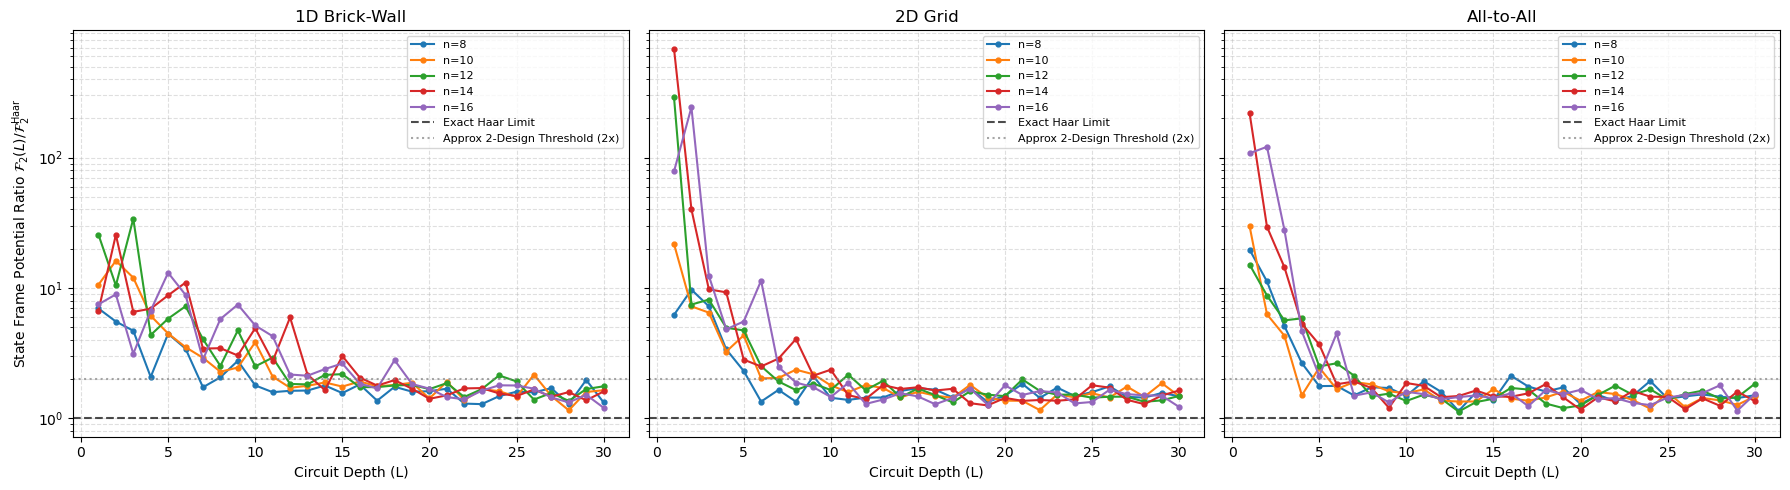

In [13]:
# ============================================================
# CELL 13 — PLOT: STATE FRAME POTENTIAL DECAY ACROSS ARCHITECTURES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
arch_titles = {"brickwall_1d": "1D Brick-Wall", "grid_2d": "2D Grid", "all_to_all": "All-to-All"}

for ax, arch in zip(axes, ARCHITECTURES):
    sub = fp_df[fp_df["architecture"] == arch]
    for n in SYSTEM_SIZES:
        sn = sub[sub["n"] == n]
        if len(sn) > 0:
            ax.plot(sn["depth"], sn["ratio_to_haar"], marker="o", markersize=3.5, label=f"n={n}")
    
    ax.axhline(1.0, color="black", linestyle="--", alpha=0.7, label="Exact Haar Limit")
    ax.axhline(2.0, color="gray", linestyle=":", alpha=0.7, label="Approx 2-Design Threshold (2x)")
    ax.set_yscale("log")
    ax.set_title(f"{arch_titles[arch]}")
    ax.set_xlabel("Circuit Depth (L)")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"State Frame Potential Ratio $\mathcal{F}_2(L) / \mathcal{F}_2^{\mathrm{Haar}}$")
plt.tight_layout()
p1_path = os.path.join(OUTPUT_DIR, "state_frame_potential_decay.png")
plt.savefig(p1_path, dpi=300)
print(f"Saved: {p1_path}")
plt.show()

### Cell 14 — Plot: Parity Plot Tau_BP vs. Tau_State_2Design


Saved: notebook10_theory_2design\tau_vs_state_2design_parity.png


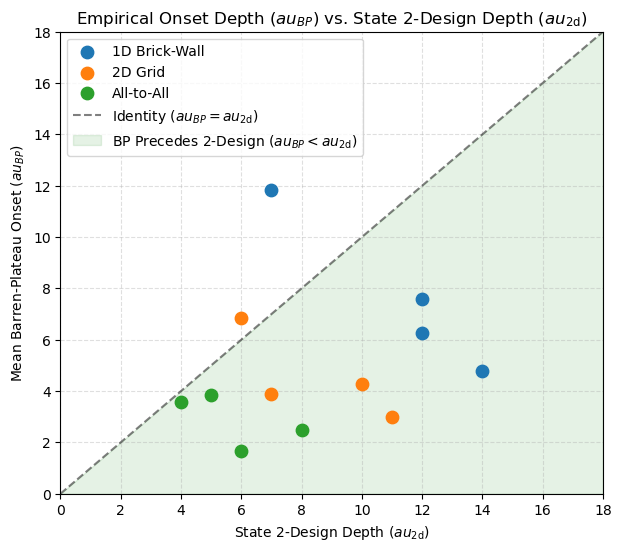

In [14]:
# ============================================================
# CELL 14 — PLOT: PARITY PLOT TAU_BP VS. TAU_STATE_2DESIGN
# ============================================================

plt.figure(figsize=(7, 6))
colors_map = {"brickwall_1d": "tab:blue", "grid_2d": "tab:orange", "all_to_all": "tab:green"}

for arch in ARCHITECTURES:
    sub = comparison_summary_df[comparison_summary_df["architecture"] == arch].dropna(subset=["depth_state_2design", "mean_tau_BP"])
    if len(sub) > 0:
        plt.scatter(sub["depth_state_2design"], sub["mean_tau_BP"], color=colors_map[arch], s=80, label=arch_titles[arch], zorder=4)

valid_d = comparison_summary_df["depth_state_2design"].dropna()
valid_t = comparison_summary_df["mean_tau_BP"].dropna()

if len(valid_d) > 0 and len(valid_t) > 0:
    max_val = max(valid_d.max(), valid_t.max()) + 2
else:
    max_val = 30

plt.plot([0, max_val], [0, max_val], "k--", alpha=0.5, label=r"Identity ($	au_{BP} = 	au_{2\mathrm{d}}$)")
plt.fill_between([0, max_val], 0, [0, max_val], color="green", alpha=0.1, label=r"BP Precedes 2-Design ($	au_{BP} < 	au_{2\mathrm{d}}$)")

plt.title(r"Empirical Onset Depth ($	au_{BP}$) vs. State 2-Design Depth ($	au_{2\mathrm{d}}$)")
plt.xlabel(r"State 2-Design Depth ($	au_{2\mathrm{d}}$)")
plt.ylabel(r"Mean Barren-Plateau Onset ($	au_{BP}$)")
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend(loc="upper left")
plt.grid(True, ls="--", alpha=0.4)

p2_path = os.path.join(OUTPUT_DIR, "tau_vs_state_2design_parity.png")
plt.savefig(p2_path, dpi=300)
print(f"Saved: {p2_path}")
plt.show()

### Cell 15 — Save Checkpoint 10 Protocol & Provenance


In [15]:
# ============================================================
# CELL 15 — SAVE CHECKPOINT 10 PROTOCOL & PROVENANCE
# ============================================================

protocol = {
    "checkpoint": 10,
    "experiment": "state_2design_consistency_check",
    "architectures": ARCHITECTURES,
    "system_sizes": SYSTEM_SIZES,
    "max_depth": MAX_DEPTH,
    "ensemble_size": N_ENSEMBLE,
    "simulator": SIMULATOR,
    "pennylane_version": qml.__version__,
    "estimator_type": "Unbiased Off-Diagonal U-Statistic",
    "formula": "1 / (M * (M - 1)) * sum_{i != j} |<psi_i|psi_j>|^4",
    "haar_target_formula": "2 / (d * (d + 1))",
    "state_2design_criterion": "F2 / Haar <= 2.0",
    "tau_source": TAU_FILE,
    "master_seed": MASTER_SEED,
}

with open(os.path.join(OUTPUT_DIR, "checkpoint10_protocol.json"), "w") as f:
    json.dump(protocol, f, indent=2)

print("=" * 80)
print("CHECKPOINT 10 PACKAGE SAVED SUCCESSFULLY")
print("=" * 80)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    p = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(p):
        print(f"  {fname} ({os.path.getsize(p):,} bytes)")
print("\nSTATUS: READY FOR VALIDATION & EXECUTION")

CHECKPOINT 10 PACKAGE SAVED SUCCESSFULLY
  checkpoint10_protocol.json (634 bytes)
  state_2design_summary.csv (1,184 bytes)
  state_frame_potential_curves.csv (45,217 bytes)
  state_frame_potential_decay.png (584,802 bytes)
  tau_vs_state_2design_parity.png (222,112 bytes)

STATUS: READY FOR VALIDATION & EXECUTION
